# 01 - Conjuntos de datos


En este sección respondemos la siguiente  pregunta: **¿cómo convierto un problema del mundo real
en una matriz de números $X$ sobre la que pueda trabajar un algoritmo?**




### Preparación del entorno

Ejecuta esta celda una sola vez. Las dos primeras líneas instalan paquetes que no vienen con
Anaconda; si ya los tienes, `pip` simplemente lo reporta y sigue.


In [1]:
# Paquetes que puede que no tengas instalados
%pip install -q category_encoders palmerpenguins

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets

pd.set_option('display.precision', 2)

## 1. Introducción

En este curso trataremos con algoritmos para el análisis de conjuntos de datos, como datos que pueden provenir de procesos industriales, comerciales, imagenes, documentos de texto y estructurados.   El análisis exploratorio está intimamente relacionado con la minería de datos, descubrimiento de conocimiento y los procesos (KDD Knowledge Discovery in Databases) y CRISP-DM. Los proyectos típicos de análisis de datos se pueden dividir en varias fases: preparación, preprocesamiento, análisis y postprocesamiento. En esta sección nos centraremos principalmente en las fases de preprocesamiento y análisis.

### Análisis de datos


El análisis consiste en la aplicación de algoritmos computacionales para el procesamiento y análisis de grandes conjuntos de datos. Los algoritmos y métodos utilizados son tomados de otras disciplinas científicas como estadísticas, aprendizaje automático (como en este curso), reconocimiento de patrones, teoría de sistemas, investigación de operaciones y inteligencia artificial.


### Proyecto de análisis de datos

Los proyectos de análisis de datos se pueden dividir en varias fases.

1. **Preparación** Recolección y selección de datos, generación de características.
2. **Preprocesamiento** Limpieza, filtrado, imputación, corrección, estandarización.
3. **Análisis** Visualización, correlación, clasificación, regresión, pronósticos, agrupamiento.
4. **Postprocesamiento** Interpretación, documentación, evaluación.

En el presente curso de **Aprendizaje automático** presentaremos algunas ideas básicas de la fase de preprocesamiento  y análisis que permitan realizar una exploración rápida y establecer el marco para un análisis más profundo. Nuestro estudio se centrará en algunos métodos de preprocesamiento y análisis: sobre datos estructurados y no estructurados.


## 2. ¿Qué es un conjunto de datos?

Un conjunto de datos (**dataset**) es una colección de elementos que se utiliza para responder preguntas o tomar decisiones. Un dataset generalmente consta de un conjunto de observaciones, donde cada observación está compuesta de un grupo de variables; donde las observaciones son los puntos de datos individuales y las variables son las características de los datos.

Las características pueden ser definidas en diferentes espacios y contextos, algunos de los tipos principales son:
-  **Numéricos**: este tipo de datos representan números. Pueden ser discretos (números enteros) o continuos (números con decimales). Algunos ejemplos de datos numéricos incluyen la edad, la altura, el peso y el precio.
- **Categóricos**: este tipo de datos representa categorías. Puede ser nominal (categorías sin orden inherente) u ordinal (categorías con un orden inherente). Como ejemplos de atributos categóricos podemos considerar el género, color de ojos y estado de residencia.
- **Texto**: este tipo de datos representa documentos escritos. Puede ser no estructurado (texto de forma libre) o estructurado (texto que sigue un formato específico). Ejemplos de datos  textuales incluyen reseñas de productos, tickets de atención al cliente y publicaciones en redes sociales.
- **Fecha y hora**: este tipo de datos representa fechas y horas. Puede ser absoluto (fecha y hora específicas) o relativo (una fecha u hora relativa a otra fecha u hora). Ejemplos de datos de fecha y hora incluyen fecha de nacimiento, orden fecha y hora de llegada.
- **Datos espaciales**: este tipo de datos representa ubicaciones. Pueden ser puntos (una sola ubicación), rutas (una serie de ubicaciones conectadas) o polígonos (un área cerrada). Ejemplos de datos espaciales incluyen coordenadas GPS, direcciones de calles y fronteras.

### 2.1 El dataset Iris

El dataset de Iris es uno de los conjuntos más utilizados para introducir los conceptos básicos del análisis de datos y aprendizaje automático.  El conjunto de datos Iris fue creado originalmente en 1935 por el botánico estadounidense Edgar Anderson, quien examinó la distribución geográfica de las flores de Iris en la península de Gaspé en Quebec (Canadá).
El conjunto de datos de Iris esta conformado por 150 mediciones de muestras de flores de Iris: 50 de cada una de las tres especies Iris Setosa, Iris Virginica e Iris Versicolor.  Para cada una de las 150 flores, se midieron los valores de cuatro características numéricas elegidas por Anderson: la longitud y el ancho de sépalo y pétalo, en centímetros. Desde la librería `sklearn`, en el módulo `datasets`, podemos acceder al dataset de Iris.

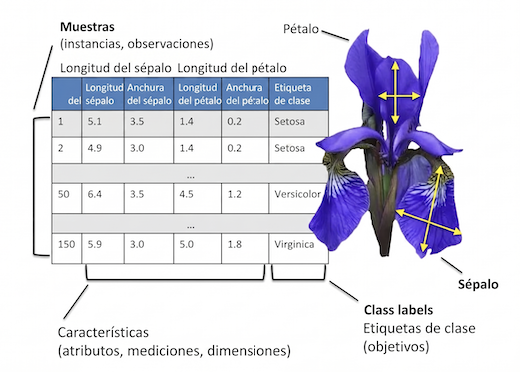

In [3]:
iris = datasets.load_iris()
X = iris.data     # matriz de caracteristicas: una fila por flor
Y = iris.target   # vector de clases: 0, 1 o 2

print('X:', X.shape, '-> 150 flores, 4 caracteristicas cada una')
print('Y:', Y.shape)

X: (150, 4) -> 150 flores, 4 caracteristicas cada una
Y: (150,)


In [4]:
print('caracteristicas:', iris.feature_names)
print('clases         :', iris.target_names)
print('primeras 10 etiquetas:', Y[:10])

caracteristicas: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
clases         : ['setosa' 'versicolor' 'virginica']
primeras 10 etiquetas: [0 0 0 0 0 0 0 0 0 0]


In [7]:
l=np.array([1,3, "a", [1]])

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (4,) + inhomogeneous part.

### 2.2 De arreglos de NumPy a un `DataFrame`

`X` y `Y` son arreglos de NumPy: eficientes para calcular, incómodos para inspeccionar. Un
`DataFrame` de `pandas` es la vista cómoda de la *misma* información: le pone nombre a cada
columna y permite mezclar tipos.

Construimos el `DataFrame` columna por columna para que cada una conserve su tipo. Un error
frecuente es apilar todo con `np.hstack` antes de crear el `DataFrame`: como NumPy exige un
tipo único por arreglo, los números se convierten en cadenas y hay que arreglarlo después.


In [12]:
df = pd.DataFrame(X, columns=iris.feature_names) # las 4 columnas numericas
df['clase'] = Y                                   # entero 0, 1, 2
df['especie'] = iris.target_names[Y]              # nombre legible
df.tail()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),clase,especie
145,6.7,3.0,5.2,2.3,2,virginica
146,6.3,2.5,5.0,1.9,2,virginica
147,6.5,3.0,5.2,2.0,2,virginica
148,6.2,3.4,5.4,2.3,2,virginica
149,5.9,3.0,5.1,1.8,2,virginica


In [11]:
set(Y)

{np.int64(0), np.int64(1), np.int64(2)}

In [6]:
df.dtypes # cada columna conserva su tipo

sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
clase                  int64
especie                  str
dtype: object

### 2.3 Preguntas que queremos responder

En el dataset cada una de las 150 flores de Iris es un objeto, cada una de las cuatro dimensiones una **característica** o **atributo**, mientras que la **clase** es la familia a la que pertenece(en la figura la utilizamos para colorear cada objeto).

A continuación listamos algunas de las preguntas típicas que tratamos de responder mediante un análisis inicial de  los datos:

-  ¿Cuál de los datos podría contener errores o asignaciones de clases falsas?
- ¿Cuál es el error que se produce al redondear los datos a un decimal?
- ¿Cuál es la correlación entre la longitud y el ancho de los pétalos?
- ¿Qué par de dimensiones está más correlacionado?
- ¿Cuál es el ancho máximo del sepalo de una flor?
- ¿Qué se esperaría de una flor que tuviera 1.8 cm como ancho de sépalo?
- ¿A qué especie pertenecería un instancia del conjunto con un ancho de sépalo de 1.8 cm?
- ¿Las tres especies contienen subespecies que se pueden identificar a partir de los datos?

Las dos últimas preguntas son, palabra por palabra, los problemas que resolveremos más
adelante: predecir la especie de una flor nueva es **clasificación** (k-NN), y descubrir
subgrupos sin usar la etiqueta es **agrupamiento** (k-centers, k-means).


### 2.4 Inspección visual

Graficamos dos de las cuatro características y coloreamos por especie. Es el primer diagnóstico
que conviene hacer siempre: dice si las clases se separan y qué tanto se traslapan.


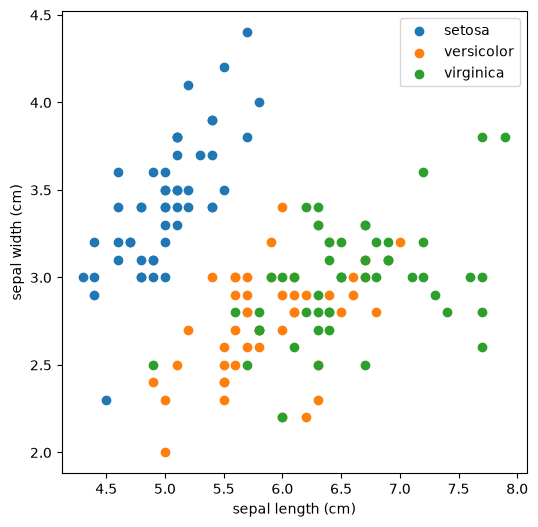

In [13]:
fig, axis = plt.subplots(figsize=(6, 6))
for clase in np.unique(df.clase):
    df_clase = df[df.clase == clase]
    axis.scatter(df_clase['sepal length (cm)'],
                 df_clase['sepal width (cm)'],
                 label=iris.target_names[clase])
axis.set_xlabel('sepal length (cm)')
axis.set_ylabel('sepal width (cm)')
axis.legend()
plt.show()

> **Ejercicio 2.1** Repite la gráfica con `petal length` y `petal width`. ¿Con qué par de
> características se separan mejor las tres especies? Esa observación reaparecerá cuando
> discutamos selección de características.


### 2.5 Resumen estadístico

`describe()` da de un golpe el conteo, la media, la desviación estándar y los cuartiles de cada
columna numérica. Fíjate en los renglones `min` y `max`: **el rango de cada característica** será
determinante  cuando calculemos distancias.


In [8]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),clase
count,150.00,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20,1.00
std,0.83,0.44,1.77,0.76,0.82
min,4.30,2.00,1.00,0.10,0.00
25%,5.10,2.80,1.60,0.30,0.00
50%,5.80,3.00,4.35,1.30,1.00
75%,6.40,3.30,5.10,1.80,2.00
max,7.90,4.40,6.90,2.50,2.00


In [14]:
print('elementos por clase:')
print(df.especie.value_counts())
print()
print('valores faltantes por columna:')
print(df.isna().sum())

elementos por clase:
especie
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

valores faltantes por columna:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
clase                0
especie              0
dtype: int64


Iris está balanceado (50 flores por especie) y no tiene valores faltantes. Es la excepción, no la
regla: al final del notebook veremos un dataset real que sí los tiene.


## 3. Escalas de medición

Las medidas numéricas pueden tener significados semánticos distintos, y las relaciones y
estadísticas que podemos aplicarles cambian según el caso. Los tipos de datos (nominal, ordinal,
intervalo, razón) deben tenerse en cuenta porque ciertas operaciones matemáticas son apropiadas
solo para algunos tipos específicos.


Escala   | Operaciones | Ejemplo | Estadisticas
-------- |-----------|-------------|------------
Razón     | $*, /$      |21 años,273K      | Media
Intervalo |$+,-$        |2000 AC, 35ºF.    | Media
Ordinal   |$>,<$        | A, B+, B, C+, C  | Mediana
Nominal   |$=, \neq$    | Rojo, verde, azul| Moda
----------------------------------------------------
**Escalas para diferentes tipos de datos**

De la tabla podemos leer por ejemplo que los datos nominales (fila inferior), solo son válidas las pruebas de igualdad o desigualdad. Los valores de una característica nominal se pueden representar mediante la moda, que se define como el valor más frecuente. Para los atributos de intervalo las operaciones de suma y resta (segunda fila) son válidas. Las características de intervalo tienen puntos cero arbitrarios en el sistema de datación Anno Domini o temperaturas en grados Celsius (centígrados) o Fahrenheit, por lo que, por ejemplo, no tiene sentido decir que 40 °C es el doble de 20 °C. Los datos de una característica a escala de intervalo, por ejemplo, un conjunto de valores $X = \{x_1,\dots, x_n\}$, se pueden representar mediante la media (conviene repasar su clase de probabilidad y estadística).

> **Ejercicio 3.1** Clasifica en la escala que corresponda: (a) el número de matrícula de un
> alumno, (b) su calificación en la escala 0–10, (c) su lugar en la lista de honor, (d) la
> temperatura del salón en °C, (e) la estatura en cm. ¿En cuáles tiene sentido calcular un
> promedio?


## 4. Representación matricial

Generalmente un conjunto de datos conformado solo de características numéricas lo representamos como

$$X=\{x_1,x_2,\dots,x_n\}$$

donde $n$ es el número de objetos/elementos en $X$, y cada elemento es un vector de características  $p$-dimensional, donde $n$ y $p$ son números enteros positivos. Para $p = 1$, llamamos a X un conjunto de datos escalares. Cuando $p>1$ el conjunto se representa como una matriz.

$$\left(
  \begin{array}{cccc}
  x_1^{(1)} & x_1^{(2)}&\dots&x_1^{(p)}\\
  x_2^{(1)} & x_2^{(2)}&\dots&x_2^{(p)}\\
  \vdots & \vdots & \dots & \vdots \\
  x_n^{(1)} & x_n^{(2)}&\dots&x_n^{(p)}\\
  \end{array}
\right)$$

donde cada vector  $x_1,\dots, x_n$ es un vector fila con $p$ elementos. Siendo laxos podemos utilizar los conjuntos de datos y las matrices  como representaciones equivalentes. Cada fila de la matriz de datos corresponde a un elemento del conjunto de datos. Cada columna de la matriz de datos corresponde a una característica de todos los elementos del conjunto de datos. Se denomina característica i-ésima o componente i-ésima $x^{(i)}, i = 1,\dots,p$.

La clase o salida asociada se representa como un vector $Y=\{y_1, y_2,\dots, y_n\}$, donde cada $y_i$ es la clase asociada al objeto $x_i \in X$


In [10]:
# La notacion del texto, sobre el dataset que ya cargamos
n, p = X.shape
print('n =', n, 'elementos')
print('p =', p, 'caracteristicas')
print()
print('x_1 (el primer elemento, un vector de p componentes):', X[0])
print('x^(1) (la primera caracteristica de todos los elementos):', X[:5, 0], '...')
print('y_1 (la clase del primer elemento):', Y[0])

n = 150 elementos
p = 4 caracteristicas

x_1 (el primer elemento, un vector de p componentes): [5.1 3.5 1.4 0.2]
x^(1) (la primera caracteristica de todos los elementos): [5.1 4.9 4.7 4.6 5. ] ...
y_1 (la clase del primer elemento): 0


Ten presente esta convención, porque no cambiará en todo el curso:

- **una fila = un objeto** (una flor, un cliente, un documento),
- **una columna = una característica** (un atributo medido sobre todos los objetos),
- $X$ es lo que recibe el algoritmo; $Y$ solo existe en problemas **supervisados**.

k-centers y k-means reciben únicamente $X$. k-NN recibe $X$ y $Y$.


## 5. Datos categóricos
En tareas de aprendizaje, es común tener que tratar con datos categóricos. Estos últimos representan categorías o etiquetas discretas y distintas, y son una parte esencial de muchos conjuntos de datos del mundo real.

Como los algoritmos que veremos operan sobre números, necesitamos convertirlas a una representación numérica. En esta sección presentamos tres estrategias de codificación y, sobre todo, **cómo elegir la correcta** según el tipo de característica.

### 5.1 Tipos de características categóricas

Como ya mencionamos, las características categóricas se pueden dividir en dos categorías: Nominales y Ordinales.

- *Nominales*. Son aquellas en las que las categorías no tienen un orden o clasificación inherente. Por ejemplo, los colores (rojo, azul, verde) son nominales porque no hay un orden natural entre ellos.
- *Ordinales*. Son aquellas en las que las categorías tienen un orden o clasificación significativa. Por ejemplo, los cinturones de Kung-fu (blanco, amarillo, verde, azul, café, negro). En este caso también son *colores*, pero cada uno representa un nivel de habilidad, y ese orden es información que no queremos perder.

La distinción no es un tecnicismo: **determina qué codificación puedes usar sin inventar información que no está en los datos.**

### 5.2 Por qué no basta con "ponerles un número"

Los datos categóricos traen consigo un conjunto de desafíos cuando se trata de análisis de datos y aprendizaje automático.
- Generalmente los métodos de aprendizaje automático operan sobre valores numéricos. Los datos categóricos, al no ser numéricos, necesitan transformarse a un formato numérico para que estos algoritmos funcionen.

- La codificación one-hot (que veremos en breve), puede llevar a un alto número de nuevas columnas (dimensiones), lo que puede aumentar la complejidad computacional (curse-of-dimensionality).

- En la codificación one-hot, las columnas recién creadas pueden estar correlacionadas, lo que puede ser problemático para algunos modelos que asumen independencia entre las características (multicolinealidad).

- Cuando se utiliza la codificación one-hot, puede llevar a matrices dispersas, donde la mayoría de las entradas son ceros. Esto puede ser ineficiente en términos de memoria y afectar el rendimiento del modelo.

### 5.3 Codificación de etiquetas (label encoding)
Esta estrategia consiste en asignar números en orden ascendente a cada categoría de una característica **ordinal**. Es un método simple pero efectivo que asigna un número entero único a cada categoría en un atributo.

Por ejemplo, si tienes una característica llamada *talla* donde los valores están definidos en el conjunto $\{S, M, L, XL \}$. Esta es una característica ordinal, ya que hay un orden inherente en las etiquetas.

Es posible codificarla como:
$
  \begin{array}{r}
    S \rightarrow 0\\
    M \rightarrow 1\\
    L \rightarrow 2\\
    XL \rightarrow 3\\
  \end{array}
$

Podemos hacer label-encoding con el método `LabelEncoder` de **scikit-learn**.

Para los ejemplos de esta sección usamos un conjunto de datos pequeño e inventado. Lo llamamos
`df_cat` para no sobrescribir el `df` de Iris, que seguimos necesitando.


In [15]:
from sklearn.preprocessing import LabelEncoder

# Datos de ejemplo
data = {
    'talla': ['S', 'M', 'L', 'XL', 'M', 'S', 'L'],
    'color_favorito': ['Rojo', 'Azul', 'Verde', 'Amarillo', 'Rojo', 'Azul', 'Verde'],
    'estatura': [165, 170, 175, 180, 168, 172, 178],
    'sexo': ['F', 'M', 'M', 'F', 'F', 'M', 'F'],
    'edad': [25, 30, 22, 29, 24, 27, 23],
    'pasatiempo':['Deporte','Leer','Video Juegos','Leer', 'Deporte', 'Video Juegos','Video Juegos']
}

# Crear el DataFrame
df_cat = pd.DataFrame(data)
df_cat

,talla,color_favorito,estatura,sexo,edad,pasatiempo
0,S,Rojo,165,F,25,Deporte
1,M,Azul,170,M,30,Leer
2,L,Verde,175,M,22,Video Juegos
3,XL,Amarillo,180,F,29,Leer
4,M,Rojo,168,F,24,Deporte
5,S,Azul,172,M,27,Video Juegos
6,L,Verde,178,F,23,Video Juegos


`LabelEncoder` de scikit-learn asigna los enteros **en orden alfabético**, no en el orden
semántico de la característica. Para `talla` eso daría `L=0, M=1, S=2, XL=3`, que no respeta
S < M < L < XL. Cuando el orden importa, conviene declararlo explícitamente con un diccionario:


In [16]:
# El orden semantico lo declaramos nosotros, no lo adivina la libreria
mapa = {"S": 0, "M": 1, "L": 2, "XL": 3}
df_cat['talla_codificada'] = [mapa[t] for t in df_cat['talla']]

# Comparacion: que habria hecho LabelEncoder por su cuenta
le = LabelEncoder()
df_cat['talla_LabelEncoder'] = le.fit_transform(df_cat['talla'])

df_cat[['talla', 'talla_codificada', 'talla_LabelEncoder']]

,talla,talla_codificada,talla_LabelEncoder
0,S,0,2
1,M,1,1
2,L,2,0
3,XL,3,3
4,M,1,1
5,S,0,2
6,L,2,0


La codificación de etiquetas es adecuada cuando:

- La característica es **ordinal**, es decir, el orden de las categorías significa algo.
- Quieres evitar aumentar la dimensionalidad del conjunto de datos: agrega una sola columna.

> **Cuidado.** No la uses en características **nominales**. Si codificas
> `Rojo=0, Azul=1, Verde=2, Amarillo=3`, cualquier método basado en distancias concluirá que
> Rojo está más cerca de Azul que de Amarillo, y que Azul está "entre" Rojo y Verde. Ese orden
> no existe en los datos: lo introdujo la codificación. Cuando el modelo se 
> construye sobre distancias, este error se propaga directo a k-means y a k-NN.


### 5.4 One-hot encoding

Esta codificación es ampliamente utilizada para convertir datos categóricos, siendo especialmente útil para características categóricas **nominales**, donde las categorías no tienen un orden inherente.

La codificación one-hot transforma cada categoría en una columna binaria. Cada columna binaria corresponde a una categoría específica e indica si el registro la presenta (1) o no (0).

Por ejemplo, considera una característica *color_favorito* con tres etiquetas. En el dataset de ejemplo tenemos los valores *Rojo*, *Verde*, *Azul*  y *Amarillo*. La codificación one-hot crearía cuatro  columnas binarias.

$
  \begin{array}{l}
    \textit{Rojo}   \rightarrow [1,0,0,0] \\
    \textit{Verde}   \rightarrow [0,1,0,0]\\
    \textit{Azul}     \rightarrow [0,0,1,0]\\
    \textit{Amarillo} \rightarrow [0,0,0,1]\\
  \end{array}
$


Con one-hot, las cuatro categorías quedan a la **misma distancia entre sí**: cualquier par de
colores distintos difiere en exactamente dos coordenadas. Eso es justo lo que queremos para una
característica nominal, y es la razón de fondo para preferirla sobre label encoding en este caso.


In [13]:
df_oh = pd.get_dummies(df_cat, columns=['color_favorito'])
df_oh.filter(like='color_favorito')

,color_favorito_Amarillo,color_favorito_Azul,color_favorito_Rojo,color_favorito_Verde
0,False,False,True,False
1,False,True,False,False
2,False,False,False,True
3,True,False,False,False
4,False,False,True,False
5,False,True,False,False
6,False,False,False,True


Verificamos la afirmación anterior: la distancia entre dos colores distintos es siempre la misma.


In [14]:
colores = pd.get_dummies(df_cat['color_favorito']).values.astype(float)
print('Rojo vs Azul    :', np.abs(colores[0] - colores[1]).sum())
print('Rojo vs Amarillo:', np.abs(colores[0] - colores[3]).sum())
print('Azul vs Verde   :', np.abs(colores[1] - colores[2]).sum())

Rojo vs Azul    : 2.0
Rojo vs Amarillo: 2.0
Azul vs Verde   : 2.0


El parámetro `drop_first=True` de `get_dummies` elimina una de las columnas (queda implícita
cuando todas las demás valen 0). Ahorra una dimensión y evita colinealidad en modelos lineales,
pero **rompe la simetría de las distancias**, así que para métodos basados en distancia como
k-means y k-NN conviene no usarlo.


### 5.5 Codificación binaria
Esta estrategia combina la codificación one-hot y la codificación de etiquetas.
Es útil para características categóricas, especialmente cuando se trata de datos con alta cardinalidad. La codificación binaria convierte cada categoría en un código binario y lo representa como una secuencia de dígitos binarios (0s y 1s). Cada dígito binario se coloca en una columna separada, creando un conjunto de columnas binarias para cada categoría.

Por ejemplo, considera el atributo *pasatiempo*. La codificación binaria implicaría asignar un código a cada categoría como sigue:



$
  \begin{array}{l}
    \textit{Leer}   \rightarrow [0,0] \\
    \textit{Video Juegos}   \rightarrow [0,1]\\
    \textit{Deporte}     \rightarrow [1,1]\\
  \end{array}
$


In [15]:
import category_encoders as ce

encoder = ce.BinaryEncoder(cols=['pasatiempo'])
encoder.fit_transform(df_cat)

,talla,color_favorito,estatura,sexo,edad,pasatiempo_0,pasatiempo_1,talla_codificada,talla_LabelEncoder
0,S,Rojo,165,F,25,0,1,0,2
1,M,Azul,170,M,30,1,0,1,1
2,L,Verde,175,M,22,1,1,2,0
3,XL,Amarillo,180,F,29,1,0,3,3
4,M,Rojo,168,F,24,0,1,1,1
5,S,Azul,172,M,27,1,1,0,2
6,L,Verde,178,F,23,1,1,2,0


In [16]:
encoder = ce.BinaryEncoder(cols=['pasatiempo', 'color_favorito'])
encoder.fit_transform(df_cat)

,talla,color_favorito_0,color_favorito_1,color_favorito_2,estatura,sexo,edad,pasatiempo_0,pasatiempo_1,talla_codificada,talla_LabelEncoder
0,S,0,0,1,165,F,25,0,1,0,2
1,M,0,1,0,170,M,30,1,0,1,1
2,L,0,1,1,175,M,22,1,1,2,0
3,XL,1,0,0,180,F,29,1,0,3,3
4,M,0,0,1,168,F,24,0,1,1,1
5,S,0,1,0,172,M,27,1,1,0,2
6,L,0,1,1,178,F,23,1,1,2,0


Combina las ventajas de la codificación one-hot y la de etiquetas: convierte los datos categóricos a formato binario usando solo $\lceil \log_2 k \rceil$ columnas para $k$ categorías, en lugar de las $k$ de one-hot. El precio es que las distancias entre categorías dejan de ser uniformes.

La codificación binaria es una opción adecuada cuando:
- Se trabaja con características categóricas de alta cardinalidad (características con un gran número de categorías únicas).
- Se desea reducir la dimensionalidad en comparación con la codificación one-hot.

### 5.6 Resumen: cuál usar

| Tipo de característica | Codificación | Columnas nuevas | Preserva distancias |
|---|---|---|---|
| Ordinal (S, M, L, XL) | etiquetas con orden declarado | 1 | sí, el orden es real |
| Nominal, pocas categorías | one-hot | $k$ | sí, todas equidistantes |
| Nominal, muchas categorías | binaria | $\lceil \log_2 k \rceil$ | no, es un compromiso |

> **Ejercicio 5.1** En `df_cat`, codifica `sexo` y `pasatiempo` con la estrategia que
> corresponda a cada una y justifica tu elección en una línea.


## 6. Datos faltantes: el dataset Palmer Penguins

Este conjunto de datos contiene información sobre tres especies de pingüinos que habitan en la península de Palmer, Antártida.  El dataset incluye diversas variables que describen a cada pingüino, como su especie (Adelie, Gentoo o Chinstrap), medidas físicas como el largo y alto del pico, la longitud de la aleta y el peso corporal, además de la isla donde se observó, el sexo y el año de la observación.

A diferencia de Iris, este dataset **sí tiene valores faltantes**, que es lo habitual en datos reales. Lo usaremos para la actividad propuesta.



In [19]:
from palmerpenguins import load_penguins

pinguinos = load_penguins()
pinguinos.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [ ]:
len

In [18]:
print('dimensiones:', pinguinos.shape)
print()
print('valores faltantes por columna:')
print(pinguinos.isna().sum())

dimensiones: (344, 8)

valores faltantes por columna:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64


Hay tres estrategias básicas ante un valor faltante, y la decisión no es automática:

1. **Eliminar** el renglón (`dropna`). Simple, pero si los faltantes no están repartidos al azar
   se introduce sesgo, y con pocos datos el costo es alto.
2. **Imputar** con un estadístico de la columna: la media o la mediana para numéricas, la moda
   para categóricas. Conserva el renglón pero reduce artificialmente la varianza.
3. **Interpolar**, cuando los renglones tienen un orden con significado (una serie de tiempo,
   por ejemplo). Ver el notebook de series de tiempo.


In [19]:
# 1. eliminar
print('renglones originales      :', len(pinguinos))
print('tras eliminar incompletos :', len(pinguinos.dropna()))

renglones originales      : 344
tras eliminar incompletos : 333


In [20]:
# 2. imputar con la mediana (numericas) y la moda (categoricas)
imputado = pinguinos.copy()
for col in imputado.columns:
    if imputado[col].isna().any():
        if pd.api.types.is_numeric_dtype(imputado[col]):
            imputado[col] = imputado[col].fillna(imputado[col].median())
        else:
            imputado[col] = imputado[col].fillna(imputado[col].mode()[0])

print('faltantes despues de imputar:', imputado.isna().sum().sum())
imputado.describe()

faltantes despues de imputar: 0


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
count,344.00,344.00,344.00,344.00,344.00
mean,43.93,17.15,200.89,4200.87,2008.03
std,5.44,1.97,14.02,799.70,0.82
min,32.10,13.10,172.00,2700.00,2007.00
25%,39.27,15.60,190.00,3550.00,2007.00
50%,44.45,17.30,197.00,4050.00,2008.00
75%,48.50,18.70,213.00,4750.00,2009.00
max,59.60,21.50,231.00,6300.00,2009.00


Compara el `describe()` de arriba con el del dataset original (celda siguiente). Las medias y
las desviaciones estándar casi no se mueven, y la razón es que solo faltan **2 de 344 valores**
en las columnas numéricas: imputar el 0.6% de los datos no puede cambiar mucho la distribución.

Lo que sí cambia es el `count`: pasa de 342 a 344. Esa es toda la ganancia, y aquí es barata.

El costo de imputar crece con la proporción de faltantes: rellenar con la mediana empuja valores
hacia el centro y **reduce artificialmente la varianza**. Con 2 faltantes es imperceptible; con
un 30% de la columna faltante, la distribución resultante ya no es la de los datos reales.
Fíjate en `sex`, con 11 faltantes: ahí la decisión sí tiene consecuencias.


In [20]:
pinguinos.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
count,342.00,342.00,342.00,342.00,344.00
mean,43.92,17.15,200.92,4201.75,2008.03
std,5.46,1.97,14.06,801.95,0.82
min,32.10,13.10,172.00,2700.00,2007.00
25%,39.23,15.60,190.00,3550.00,2007.00
50%,44.45,17.30,197.00,4050.00,2008.00
75%,48.50,18.70,213.00,4750.00,2009.00
max,59.60,21.50,231.00,6300.00,2009.00


> **Actividad**
>
> Realiza el proceso de completado de datos usando las funciones de `pandas`
> (https://pandas.pydata.org/docs/user_guide/missing_data.html) y responde:
>
> 1. ¿Cuántos renglones pierdes con `dropna()`? ¿Se pierden por igual en las tres especies?
> 2. Imputa `body_mass_g` con la media **de toda la columna** y luego con la media
>    **de la especie correspondiente** (`groupby('species')`). ¿Cuál te parece más defendible y
>    por qué?
> 3. La columna `sex` tiene faltantes. ¿Tiene sentido imputarla con la moda? ¿Qué información
>    estarías inventando?


## 7. Qué sigue

Ya sabemos convertir un problema en una matriz $X$: elegir características, codificar las
categóricas y tratar los faltantes.

En el la siguiene sección aboardaremos la siguiente pregunta: dados dos renglones de $X$, ¿cómo medimos
qué tan parecidos son? De ahí sale la matriz de distancias $R$, que es literalmente la entrada
de algoritmos como **K-Means** o **Nearest Centroids** que implementaremos después.

Dos cosas que recordar:

- La sección 2.5, donde vimos que cada característica tiene **un rango distinto**.
- La sección 5, donde vimos que una codificación mal elegida **inventa distancias** que no
  existen en los datos.
